# CREACIÓN DE UNA RED NEURONAL PARA CLASIFICAR LA ESPECIE DE PINGUINO

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

# Cargar dataset
df = sns.load_dataset("penguins")
df = df.dropna()  # Eliminar filas con valores nulos
df




,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,Male
...,...,...,...,...,...,...,...
338,Gentoo,Biscoe,47.2,13.7,214.0,4925.0,Female
340,Gentoo,Biscoe,46.8,14.3,215.0,4850.0,Female
341,Gentoo,Biscoe,50.4,15.7,222.0,5750.0,Male
342,Gentoo,Biscoe,45.2,14.8,212.0,5200.0,Female


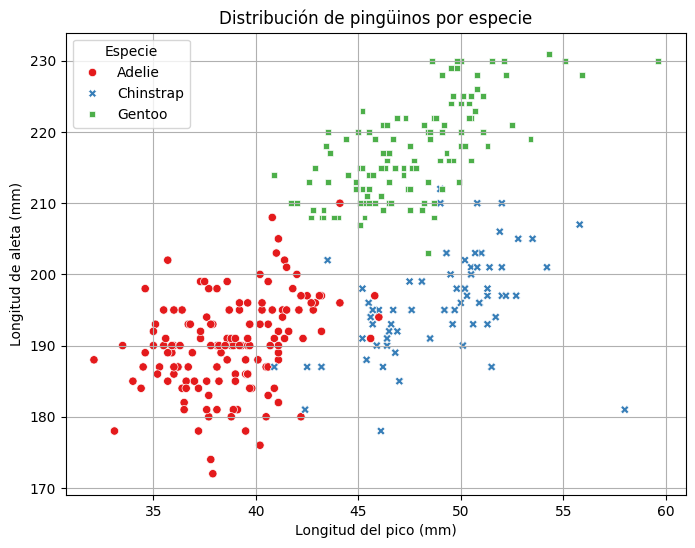

In [6]:
# Scatter plot
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df,
    x="bill_length_mm",
    y="flipper_length_mm",
    hue="species",
    style="species",
    palette="Set1"
)
plt.title("Distribución de pingüinos por especie")
plt.xlabel("Longitud del pico (mm)")
plt.ylabel("Longitud de aleta (mm)")
plt.grid(True)
plt.legend(title="Especie")
plt.show()

In [7]:
df.dtypes

,0
species,object
island,object
bill_length_mm,float64
bill_depth_mm,float64
flipper_length_mm,float64
body_mass_g,float64
sex,object


# CREACIÓN DE MODELO DE RED NEURONAL

## PASO 1 - IMPORTAMOS LIBRERIAS NECESARIAS

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler,LabelEncoder
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense


## PASO 2 - IDENTIFICAR VARIABLE X Y Y

In [9]:
X = df[['bill_length_mm', 'flipper_length_mm']]
y = df['species']

## PASO 3 - CODIFICAR VARIABLES CATEGORICAS

In [11]:
le = LabelEncoder()
y_encoded = le.fit_transform(y)  # Ej: Adelie=0, Chinstrap=1, Gentoo=2
y_onehot = tf.keras.utils.to_categorical(y_encoded)

## PASO 4 - ESCALAMIENTO DE DATOS

In [12]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

## PASO 5 - DIVIDIMOS DATASET EN ENTRENAMIENTO Y PRUEBA

In [13]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_onehot, test_size=0.2, random_state=42)

## PASO 6 - CREAMOS UNA RED NEURONAL NEURONAL SECUENCIAL

In [14]:
model = Sequential([
    Dense(8,activation='relu',input_shape=(2,)),
    Dense(6,activation='relu'),
    Dense(3,activation='softmax')
])

## PASO 7 - COMPILAMOS LA RED

In [15]:
model.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['accuracy'])

# PASO 8 - ENTRENAMOS LA RED NEURONAL

In [16]:
model.fit(X_train,y_train,epochs=20,batch_size=8,validation_split=0.2)

Epoch 1/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.1664 - loss: 1.4993 - val_accuracy: 0.4815 - val_loss: 1.3435
Epoch 2/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5201 - loss: 1.3076 - val_accuracy: 0.5185 - val_loss: 1.2170
Epoch 3/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4913 - loss: 1.2729 - val_accuracy: 0.5185 - val_loss: 1.0870
Epoch 4/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5701 - loss: 1.0650 - val_accuracy: 0.5185 - val_loss: 0.9695
Epoch 5/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5504 - loss: 0.9440 - val_accuracy: 0.5370 - val_loss: 0.8729
Epoch 6/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5936 - loss: 0.8590 - val_accuracy: 0.6111 - val_loss: 0.7924
Epoch 7/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6605 - loss: 0.7626 - val_accuracy: 0.6296 - val_loss: 0.7204
Epoch 8/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7310 - loss: 0.7425 - val_accuracy: 0.7593 - val_los

## PASO 9 - EVALUAMOS LA RED NEURONAL

In [17]:
loss, accuracy = model.evaluate(X_test, y_test)
print(f"Accuracy en test: {accuracy:.2f}")

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.9808 - loss: 0.1190
Accuracy en test: 0.99


In [18]:
# Predecir algunos resultados
predictions = model.predict(X_test[:5])
print("Predicciones:", le.inverse_transform(np.argmax(predictions, axis=1)))
print("Reales:", le.inverse_transform(np.argmax(y_test[:5], axis=1)))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 222ms/step
Predicciones: ['Adelie' 'Gentoo' 'Adelie' 'Chinstrap' 'Adelie']
Reales: ['Adelie' 'Gentoo' 'Adelie' 'Chinstrap' 'Adelie']
